📅 **论文年份 (Year):2021 年**
*Learning Transferable Visual Models From Natural Language Supervision (CLIP) — Radford et al., OpenAI*

# Bonus Paper 31: CLIP(对比语言-图像预训练)
## Radford et al., OpenAI(拉德福德等)

### Implementation: Toy CLIP with Contrastive Image-Text Learning(实现：基于对比学习的玩具版 CLIP)

This notebook implements the core idea of CLIP using only NumPy: train an image encoder and a text encoder jointly so that matching image-text pairs have high cosine similarity, then perform **zero-shot classification** with natural language prompts.

本笔记本只用 NumPy 实现 CLIP 的核心思想：联合训练一个图像编码器和一个文本编码器,让配对的图文在共享嵌入空间中余弦相似度最高,然后用自然语言提示词(prompt)做**零样本分类(zero-shot classification)**。

> 注:CLIP 不在 Sutskever 原始 30 篇书单中,是本仓库的多模态扩展(Bonus)。它是现代视觉-语言模型(VLM,如 LLaVA、GPT-4V)的基石。

## 📖 论文导读

**🎯 这篇文章想解决什么问题(目的):** 传统图像分类模型(如 AlexNet、ResNet)有一个根本性局限:它们只能预测训练时定死的那 1000 个类别标签,换一个任务就得重新标注数据、重新训练。而互联网上有海量"图片 + 文字描述"的天然配对数据,却没被利用。CLIP 想回答:能否直接从自然语言监督中学习视觉表示,让一个模型无需微调就能做任意分类任务?

**💡 主要贡献:** CLIP 用 4 亿个网络图文对训练了一个双塔模型(图像编码器 + 文本编码器),证明了:(1) 对比学习目标(而非预测精确文字)在这种规模下学习效率最高;(2) 训练好的模型只靠一句"a photo of a {class}"提示词,就能在 ImageNet 上达到与有监督 ResNet-50 相当的零样本准确率;(3) 这种表示迁移到 30 多个下游任务时鲁棒性远超传统监督模型。

**🔧 方法:** 一个 batch 内有 N 个图文对,把 N 张图和 N 段文字分别编码成 L2 归一化的向量,计算 N×N 的余弦相似度矩阵;训练目标是让对角线(正确配对)的相似度远高于其余 N²−N 个错误配对——即对称的 InfoNCE 对比损失,配一个可学习的温度参数。本笔记本用彩色几何图形(3 种颜色 × 3 种形状)作为"图像",词袋句子("a red circle")作为"文本",完整复现这一训练流程,包括手写反向传播。

**🌟 意义:** CLIP 让"用语言定义类别"取代了"用标注定义类别",开启了开放词表视觉的时代。它的图像编码器成为后续几乎所有 VLM(LLaVA、Flamingo、GPT-4V)的视觉前端,文本-图像对齐的嵌入空间也直接催生了 DALL·E 2、Stable Diffusion 等文生图模型。理解 CLIP,就理解了多模态模型如何"把两种模态钉进同一个空间"。

## 🎯 核心结论 (Key Takeaways)

- **对比学习就是"连连看"。** 一个 batch 里 N 对图文,模型只需学会把 N×N 相似度矩阵的对角线拉高、其余压低。本实验中这样训练出的模型对 8 个见过的"颜色×形状"类别达到 **93% 零样本准确率**——分类器完全由文字提示词构成,训练时从未见过"分类"这个任务。

- **温度参数是对比学习的灵魂旋钮。** 相似度要除以温度 τ(CLIP 初始化为 0.07 并设为可学习):τ 太大则所有配对难以区分,太小则梯度只集中在最难样本上。本实验中温度从 0.07 出发,训练后稳定在约 0.066。

- **重复标题给损失设置了理论下限。** 玩具数据只有 8 种标题,batch=64 时每种标题平均重复 8 次,InfoNCE 无法区分内容相同的文本,损失被卡在约 ln(8)≈2.08 附近、batch 内配对准确率约 1/8——这不是 bug,而是对比学习的数学性质。真实 CLIP 依赖 4 亿条**几乎不重复**的自然语言标题,多样性本身就是监督信号。

- **零样本分类 = 检索。** 推理时把每个候选类别写成一句话、编码成向量,图像分类就变成"在文本向量中检索最近邻"。改类别只需改提示词,不用动模型——这就是"用语言定义类别"。

- **组合泛化没有免费午餐。** 从训练集中扣掉"blue triangle"后,模型对这个新组合的零样本准确率只有约 20%(随机为 11%)——远低于见过类别的 93%。真实 CLIP 的开放词表能力主要来自数据的规模与多样性,而非对比目标本身自带组合推理。

## 🤯 反常识的发现 (Counterintuitive Findings)

- **常识认为:分类器需要"分类头",类别数定死在网络结构里。** CLIP 证明分类头可以在推理时用自然语言现场"写"出来:本实验中 8 个类别的分类器就是 8 句话的嵌入向量,准确率 93%。增删类别 = 增删句子,零成本。

- **常识认为:损失降不下去说明训练失败了。** 本实验损失稳定在 2.1 附近"不动了",batch 准确率只有 12%,看似完全没学会;但零样本测试却有 93% 准确率。原因是 batch 内大量重复标题让 InfoNCE 存在 ln(8) 的理论下限——模型其实早已学好,只是指标被数据的重复性"污染"了。**看懂损失的下限比盯着损失数值更重要。**

- **常识认为:学会了"blue"和"triangle",自然就认识"blue triangle"。** 文本端确实如此(词袋向量天然可组合),但图像编码器从未见过蓝色三角形的像素组合,特征纠缠导致新组合准确率仅约 20%。**模态间的组合泛化是数据规模买来的,不是架构送的**——这解释了为什么 CLIP 必须用 4 亿图文对训练。

- **常识认为:两个不同模态的编码器各学各的,空间对不上。** 对比损失恰恰是把两个独立网络的输出"焊"进同一个球面空间的焊枪:训练前图文相似度矩阵是一片噪声,训练后对角线清晰浮现——对齐(alignment)不需要共享参数,只需要共享目标。

#### 💻 代码解读

**做什么:** 导入依赖并固定随机种子,保证实验可复现。

**怎么做:**
- 只用 `numpy`(数值计算)和 `matplotlib`(画图),与本仓库其他 30 个 notebook 保持一致——不依赖任何深度学习框架。
- `deepcopy` 用于在训练前保存一份"未训练"的编码器,后面做训练前/后对比图。
- 固定两个随机源:全局 `np.random.seed` 和新式 `default_rng`,数据生成与参数初始化都走 `rng`,结果完全可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

np.random.seed(42)
# 新式随机数生成器:数据生成、参数初始化、采样都用它,保证可复现
rng = np.random.default_rng(0)

## Synthetic Image-Text Dataset(合成图文数据集)

#### 💻 代码解读

**做什么:** 构造一个微型"图文对"数据集:图像是 16×16 的彩色几何图形(3 种颜色 × 3 种形状 = 9 个概念),文本是对应的三词句子(如 "a red circle")。

**怎么做:**
- `draw_image`:在带噪声的黑色背景上画一个随机位置、随机大小的图形。用 `np.mgrid` 生成全部像素坐标,再用布尔掩码(mask)一次性选中图形内的像素——圆用距离方程、方形用切比雪夫距离、三角形用两条斜边不等式,这是 NumPy 向量化画图的典型技巧。
- `caption_bow`:把句子表示成词袋(bag-of-words)向量——7 维向量,每个词出现次数 +1。真实 CLIP 用 Transformer 编码完整句子,这里用词袋保持极简。
- `make_dataset`:默认**扣掉 "blue triangle" 这个组合**(holdout),只用其余 8 类训练——留到最后测试组合泛化。
- 最后画出 9 个概念的示例图,标题即其配对文本。

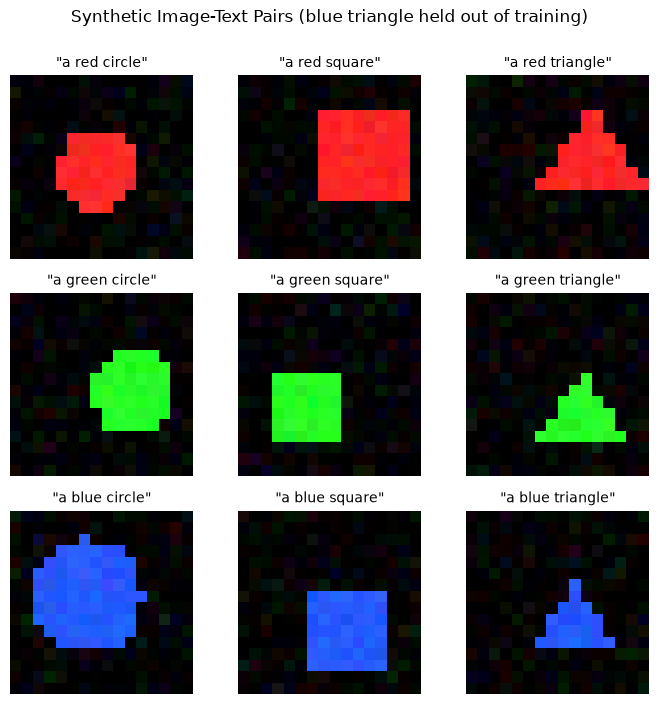

Training set: 2000 pairs, image dim=768, text dim=7
Training covers 8 of 9 concepts (blue triangle excluded)


In [2]:
# 3种颜色 × 3种形状 = 9个视觉概念
COLORS = {'red': (1.0, 0.15, 0.15), 'green': (0.15, 1.0, 0.15), 'blue': (0.15, 0.35, 1.0)}
SHAPES = ['circle', 'square', 'triangle']
VOCAB = ['a', 'red', 'green', 'blue', 'circle', 'square', 'triangle']
W2I = {w: i for i, w in enumerate(VOCAB)}
IMG = 16  # 图像尺寸 16x16x3

def draw_image(color, shape, rng):
    """Draw one colored shape with position/size jitter and noise"""
    img = np.zeros((IMG, IMG, 3))
    img += rng.normal(0, 0.04, img.shape)  # background noise
    # 位置和大小随机抖动:迫使编码器学"概念"而不是死记像素位置
    cx, cy = rng.uniform(5.5, 10.5, 2)
    r = rng.uniform(3.0, 5.0)
    # np.mgrid一次生成所有像素的(行,列)坐标网格,形状均为(16,16)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    if shape == 'circle':
        # 布尔掩码:到圆心距离平方<=r^2的像素为True,向量化代替双重循环
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    elif shape == 'square':
        mask = (np.abs(xx - cx) <= r * 0.8) & (np.abs(yy - cy) <= r * 0.8)
    else:  # triangle
        # 三角形=三条边的半平面交集:顶点在上,宽度随y线性增大
        mask = (yy - (cy - r) >= 0) & (yy - (cy - r) <= 1.5 * r) & \
               (np.abs(xx - cx) <= (yy - (cy - r)) / 1.5)
    # 花式索引:mask为True的所有像素一次性赋成该颜色
    img[mask] = COLORS[color]
    img += rng.normal(0, 0.03, img.shape)
    return np.clip(img, 0, 1)

def caption_bow(color, shape):
    """Caption 'a {color} {shape}' as bag-of-words vector"""
    # 词袋表示:7维向量记录每个词出现次数,丢弃词序(真实CLIP用Transformer)
    v = np.zeros(len(VOCAB))
    for w in ['a', color, shape]:
        v[W2I[w]] += 1
    return v

def make_dataset(n, rng, holdout=('blue', 'triangle'), include_holdout=False):
    """Generate n image-text pairs; 'blue triangle' held out from training"""
    X_img, X_txt, labels = [], [], []
    pairs = [(c, s) for c in COLORS for s in SHAPES]
    # 训练集扣掉holdout组合(8类);include_holdout=True时则只生成holdout(用于测试)
    train_pairs = [p for p in pairs if p != holdout] if not include_holdout else [holdout]
    for _ in range(n):
        c, s = train_pairs[rng.integers(len(train_pairs))]
        # 图像展平成768维向量(16*16*3),方便直接输入MLP
        X_img.append(draw_image(c, s, rng).reshape(-1))
        X_txt.append(caption_bow(c, s))
        labels.append(pairs.index((c, s)))
    return np.array(X_img), np.array(X_txt), np.array(labels), pairs

ALL_PAIRS = [(c, s) for c in COLORS for s in SHAPES]

# 可视化9个概念各一个样本
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for ax, (c, s) in zip(axes.flat, ALL_PAIRS):
    ax.imshow(draw_image(c, s, rng))
    ax.set_title(f'"a {c} {s}"', fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic Image-Text Pairs (blue triangle held out of training)', y=1.0)
plt.tight_layout()
plt.show()

Xi, Xt, y_train, _ = make_dataset(2000, rng)
print(f'Training set: {len(Xi)} pairs, image dim={Xi.shape[1]}, text dim={Xt.shape[1]}')
print(f'Training covers 8 of 9 concepts (blue triangle excluded)')

## Dual Encoders: Image Tower & Text Tower(双塔编码器:图像塔与文本塔)

#### 💻 代码解读

**做什么:** 实现 CLIP 的双塔结构——两个完全独立的 2 层 MLP,分别把图像(768 维)和文本(7 维)映射到**同一个 32 维单位球面**上。

**怎么做:**
- `init_mlp`:He 初始化(标准差 √(2/fan_in)),适配 ReLU 激活,防止深层信号消失。
- `mlp_forward`:线性 → ReLU → 线性,最后做 **L2 归一化**——这一步至关重要:归一化后向量都在单位球面上,内积 = 余弦相似度,相似度范围被固定在 [-1,1],温度参数才有意义。
- `mlp_backward`:手写反向传播。最精妙的是**穿过 L2 归一化的梯度**:对 z_n=z/‖z‖,雅可比是 (I − z_n z_nᵀ)/‖z‖,直觉是"把梯度中沿向量自身方向的分量投影掉"——因为沿半径方向移动不改变归一化结果。
- 返回的 cache 保存前向中间量,反向传播按链式法则逐层回传。

In [3]:
D_EMB = 32  # 共享嵌入空间维度:图像塔和文本塔的输出都落在这个空间

def init_mlp(d_in, d_h, d_out, rng):
    # He初始化:std=sqrt(2/fan_in),与ReLU搭配防止方差逐层衰减
    return {
        'W1': rng.normal(0, np.sqrt(2 / d_in), (d_in, d_h)), 'b1': np.zeros(d_h),
        'W2': rng.normal(0, np.sqrt(2 / d_h), (d_h, d_out)), 'b2': np.zeros(d_out),
    }

def mlp_forward(p, x):
    """Linear -> ReLU -> Linear -> L2 normalize"""
    h_pre = x @ p['W1'] + p['b1']
    h = np.maximum(h_pre, 0)
    z = h @ p['W2'] + p['b2']
    # L2归一化到单位球面:之后内积=余弦相似度;+1e-8防除零
    norm = np.linalg.norm(z, axis=1, keepdims=True) + 1e-8
    zn = z / norm
    # cache保存中间量供反向传播使用
    return zn, (x, h_pre, h, z, norm, zn)

def mlp_backward(p, cache, dzn):
    """Manual backprop through the MLP (chain rule, layer by layer)"""
    x, h_pre, h, z, norm, zn = cache
    # 穿过L2归一化的梯度:投影掉沿zn自身方向的分量,再除以norm
    # 直觉:沿半径方向移动不改变归一化结果,该方向梯度必须为0
    dz = (dzn - (dzn * zn).sum(1, keepdims=True) * zn) / norm
    g = {}
    g['W2'] = h.T @ dz
    g['b2'] = dz.sum(0)
    dh = dz @ p['W2'].T
    # ReLU的梯度:前向为正的位置通过,为负的位置截断为0
    dh_pre = dh * (h_pre > 0)
    g['W1'] = x.T @ dh_pre
    g['b1'] = dh_pre.sum(0)
    return g

img_enc = init_mlp(IMG * IMG * 3, 256, D_EMB, rng)  # 图像塔: 768->256->32
txt_enc = init_mlp(len(VOCAB), 64, D_EMB, rng)      # 文本塔: 7->64->32
n_img = sum(v.size for v in img_enc.values())
n_txt = sum(v.size for v in txt_enc.values())
print(f'Image encoder params: {n_img:,} | Text encoder params: {n_txt:,}')

Image encoder params: 205,088 | Text encoder params: 2,592


## Symmetric InfoNCE Contrastive Loss(对称 InfoNCE 对比损失)

#### 💻 代码解读

**做什么:** 实现 CLIP 的核心训练目标——对称 InfoNCE 损失及其解析梯度,外加 Adam 优化器。

**怎么做:**
- `softmax_rows`:逐行 softmax,先减去每行最大值防止 e^x 上溢(数值稳定标准技巧)。
- `clip_loss_and_grads`:
  - 相似度矩阵 `logits = s · Z_img @ Z_txtᵀ`,形状 (N,N),第 (i,j) 元素是第 i 张图与第 j 段文本的余弦相似度,`s = e^{log_scale}` 是可学习的温度倒数(CLIP 初始化 τ=0.07);
  - 按行 softmax = "每张图在 N 段文本中找自己的标题",按列 softmax = "每段文本找自己的图",两个方向的交叉熵取平均——**正确答案永远在对角线上**;
  - 梯度惊人地简洁:`G = ½[(P_row − I) + (P_col − I)ᵀ]/N`,即"预测概率减 one-hot 真值"的对称版;再经 `dzi = s·G@zt` 回传到两个塔。
  - 温度的梯度 `dlog_scale` 也一并解析求出,让模型自己学习区分度的"锐利程度"。
- `adam_update`:标准 Adam,含偏差修正(除以 1−β^t,修正初期动量偏向 0 的问题)。

In [4]:
def softmax_rows(L):
    # 数值稳定技巧:每行减去最大值再取exp,防止溢出;softmax结果不变
    L = L - L.max(1, keepdims=True)
    e = np.exp(L)
    return e / e.sum(1, keepdims=True)

def clip_loss_and_grads(zi, zt, log_scale):
    """Symmetric InfoNCE: match images to texts and texts to images"""
    n = zi.shape[0]
    # 温度以log形式参数化:保证exp后恒为正,且优化更稳定
    s = np.exp(log_scale)
    # (N,N)相似度矩阵:元素(i,j)=第i张图与第j段文本的余弦相似度×s
    logits = s * zi @ zt.T
    Pr = softmax_rows(logits)      # 按行:每张图在N段文本中"认领"标题
    Pc = softmax_rows(logits.T)    # 按列:每段文本在N张图中"认领"图像
    eye = np.eye(n)
    # 对角线即正确配对;取两个方向交叉熵的平均(对称损失)
    loss = -0.5 * (np.log(Pr[np.arange(n), np.arange(n)] + 1e-12).mean()
                   + np.log(Pc[np.arange(n), np.arange(n)] + 1e-12).mean())
    # 交叉熵对logits的梯度=预测概率-真值(one-hot对角阵),两方向对称平均
    G = 0.5 * ((Pr - eye) + (Pc - eye).T) / n
    dzi = s * G @ zt
    dzt = s * G.T @ zi
    # 温度也是可学习参数:dL/dlog_scale = sum(G⊙原始相似度)×s
    dlog_scale = np.sum(G * (zi @ zt.T)) * s
    acc = (logits.argmax(1) == np.arange(n)).mean()
    return loss, dzi, dzt, dlog_scale, acc

def adam_update(p, g, m, v, t, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    for k in p:
        m[k] = b1 * m[k] + (1 - b1) * g[k]
        v[k] = b2 * v[k] + (1 - b2) * g[k] ** 2
        # 偏差修正:除以(1-beta^t),抵消动量初始化为0造成的低估
        mh = m[k] / (1 - b1 ** t)
        vh = v[k] / (1 - b2 ** t)
        p[k] -= lr * mh / (np.sqrt(vh) + eps)

print('Loss, analytic gradients, and Adam ready.')

Loss, analytic gradients, and Adam ready.


## Training Loop(训练循环)

#### 💻 代码解读

**做什么:** 用对比损失联合训练双塔 2000 步,并记录损失与温度的演化曲线。

**怎么做:**
- 训练前用 `deepcopy` 快照未训练的编码器,供后面"训练前 vs 训练后"对比。
- 每步随机采 64 个图文对 → 双塔前向 → 计算损失和梯度 → 各自反向传播 → Adam 更新;温度参数单独用一份标量 Adam 更新,并按 CLIP 论文习惯做裁剪(clip)防止爆炸。
- **注意损失只降到 ~2.1 就"停住"了**:batch=64 但只有 8 种标题,每种平均重复 8 次,InfoNCE 无法区分内容相同的文本,损失存在 ln(8)≈2.08 的理论下限,batch 配对准确率也被卡在约 1/8。右图同时画出这条下限——**模型其实已经学好了**,后面的零样本测试会证明这一点。

step 400: loss=2.1557  batch_acc=0.12  temperature=0.0691


step 800: loss=2.1339  batch_acc=0.12  temperature=0.0672


step 1200: loss=2.1186  batch_acc=0.12  temperature=0.0667


step 1600: loss=2.1243  batch_acc=0.12  temperature=0.0665


step 2000: loss=2.1193  batch_acc=0.12  temperature=0.0662


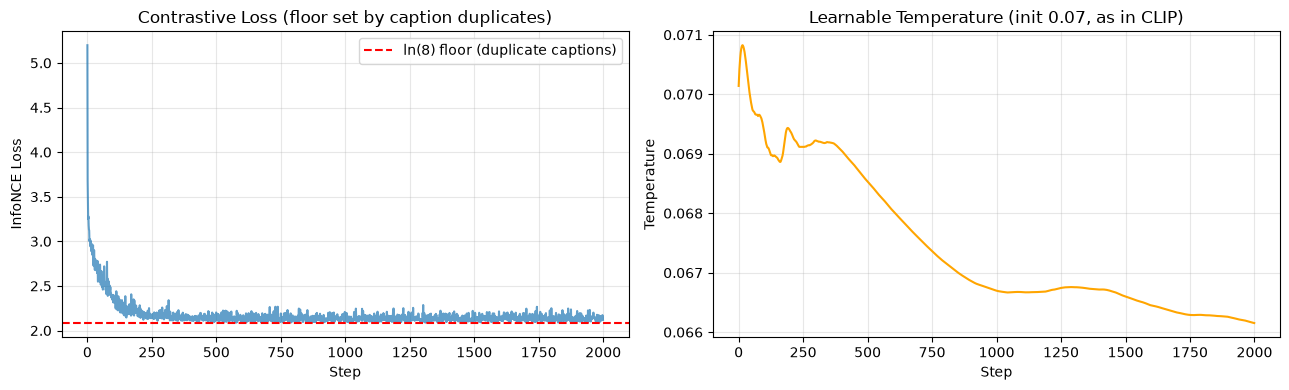

In [5]:
# 训练前快照:留作"训练前vs训练后"的对比基线
img_enc_untrained = deepcopy(img_enc)
txt_enc_untrained = deepcopy(txt_enc)

log_scale = np.log(1 / 0.07)  # CLIP论文的温度初始化:tau=0.07
mi = {k: np.zeros_like(v) for k, v in img_enc.items()}
vi = {k: np.zeros_like(v) for k, v in img_enc.items()}
mt = {k: np.zeros_like(v) for k, v in txt_enc.items()}
vt = {k: np.zeros_like(v) for k, v in txt_enc.items()}
ms = vs = 0.0  # 温度参数自己的一份Adam动量
B = 64
loss_hist, temp_hist = [], []

for step in range(1, 2001):
    idx = rng.integers(0, len(Xi), B)
    zi, ci = mlp_forward(img_enc, Xi[idx])
    zt, ct = mlp_forward(txt_enc, Xt[idx])
    loss, dzi, dzt, dls, acc = clip_loss_and_grads(zi, zt, log_scale)
    # 两个塔独立反向传播:对比损失是它们唯一的"耦合点"
    gi = mlp_backward(img_enc, ci, dzi)
    gt = mlp_backward(txt_enc, ct, dzt)
    adam_update(img_enc, gi, mi, vi, step, lr=2e-3)
    adam_update(txt_enc, gt, mt, vt, step, lr=2e-3)
    # 温度参数的标量Adam更新
    ms = 0.9 * ms + 0.1 * dls
    vs = 0.999 * vs + 0.001 * dls ** 2
    log_scale -= 2e-3 * (ms / (1 - 0.9 ** step)) / (np.sqrt(vs / (1 - 0.999 ** step)) + 1e-8)
    # 仿照CLIP:裁剪logit_scale上限,防止温度塌缩到0
    log_scale = min(log_scale, np.log(100.0))
    loss_hist.append(loss)
    temp_hist.append(1 / np.exp(log_scale))
    if step % 400 == 0:
        print(f'step {step}: loss={loss:.4f}  batch_acc={acc:.2f}  temperature={temp_hist[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(loss_hist, alpha=0.7)
# 理论下限:batch内每种标题平均重复8次 -> 损失下限约ln(8)
ax1.axhline(np.log(8), color='red', ls='--', label='ln(8) floor (duplicate captions)')
ax1.set_xlabel('Step'); ax1.set_ylabel('InfoNCE Loss')
ax1.set_title('Contrastive Loss (floor set by caption duplicates)')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(temp_hist, color='orange')
ax2.set_xlabel('Step'); ax2.set_ylabel('Temperature')
ax2.set_title('Learnable Temperature (init 0.07, as in CLIP)')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Similarity Matrix: Before vs After Training(相似度矩阵:训练前 vs 训练后)

#### 💻 代码解读

**做什么:** 直观展示对比学习"焊接"两个模态的过程:取 8 个训练类别各一个样本,画出 8×8 图文余弦相似度矩阵在训练前后的样子。

**怎么做:**
- 每个类别生成一张新图 + 一句标题,分别用**未训练**和**训练后**的双塔编码。
- 训练前:两个随机初始化的网络输出毫无关联,矩阵近乎均匀噪声;
- 训练后:对角线(正确配对)明显亮起——两个从未共享参数的网络,仅靠共享的对比目标就对齐到了同一个嵌入空间。注意非对角也有次级结构:同色或同形状的图文相似度略高,说明模型学到的是**可分解的语义特征**而非死记硬背。

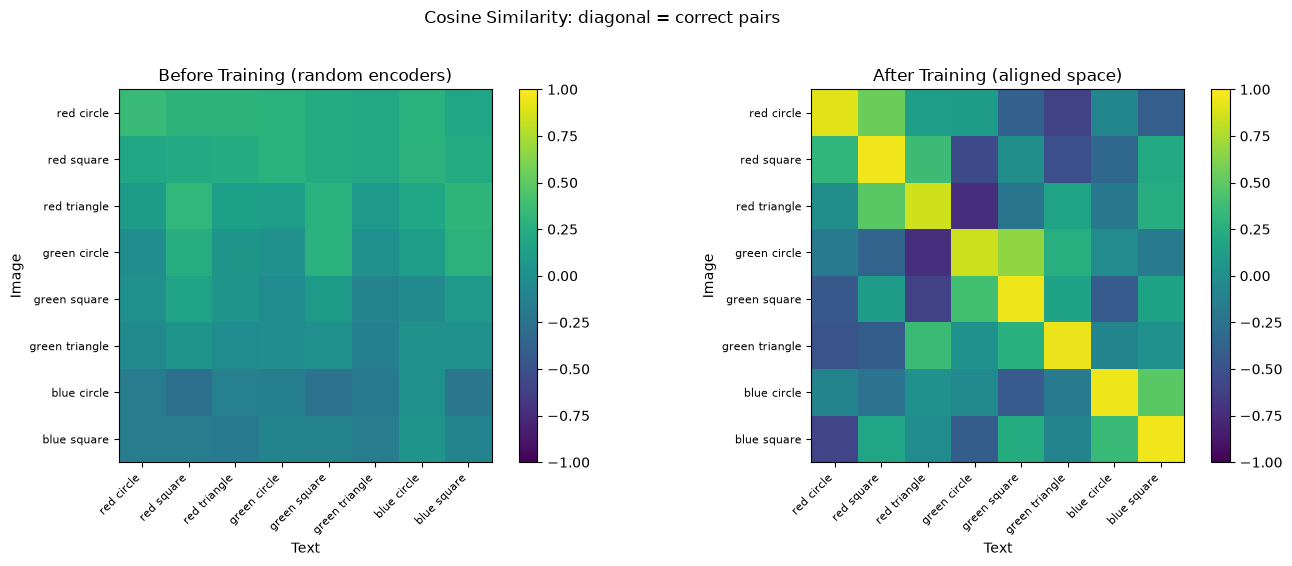

In [6]:
train_pairs = [p for p in ALL_PAIRS if p != ('blue', 'triangle')]
demo_imgs = np.array([draw_image(c, s, rng).reshape(-1) for c, s in train_pairs])
demo_txts = np.array([caption_bow(c, s) for c, s in train_pairs])
names = [f'{c} {s}' for c, s in train_pairs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (ie, te), title in zip(
        axes,
        [(img_enc_untrained, txt_enc_untrained), (img_enc, txt_enc)],
        ['Before Training (random encoders)', 'After Training (aligned space)']):
    zi_d, _ = mlp_forward(ie, demo_imgs)
    zt_d, _ = mlp_forward(te, demo_txts)
    # 双塔输出的内积矩阵:行=图像,列=文本
    sim = zi_d @ zt_d.T
    im = ax.imshow(sim, cmap='viridis', vmin=-1, vmax=1)
    ax.set_xticks(range(8)); ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(8)); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Text'); ax.set_ylabel('Image')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Cosine Similarity: diagonal = correct pairs', y=1.02)
plt.tight_layout(); plt.show()

## Zero-Shot Classification(零样本分类)

#### 💻 代码解读

**做什么:** 复现 CLIP 最惊艳的能力——不训练任何分类器,仅用 8 句话作为"类别定义",对 500 张新图像做分类。

**怎么做:**
- 把 8 个类别各写成一句 "a {color} {shape}",经文本塔编码成 8 个"类别原型向量"——这一步就是在**用语言现场构造分类器权重**。
- 新图像经图像塔编码后,与 8 个文本向量算余弦相似度,`argmax` 即预测类别(`zi @ zp.T` 一次性算出 500×8 的全部相似度,纯矩阵乘法)。
- 结果:整体准确率约 93%,各类别均衡——而模型训练时只做过"图文连连看",从未见过"分类"任务。

Zero-shot accuracy on 8 seen classes: 93.2%  (chance = 12.5%)


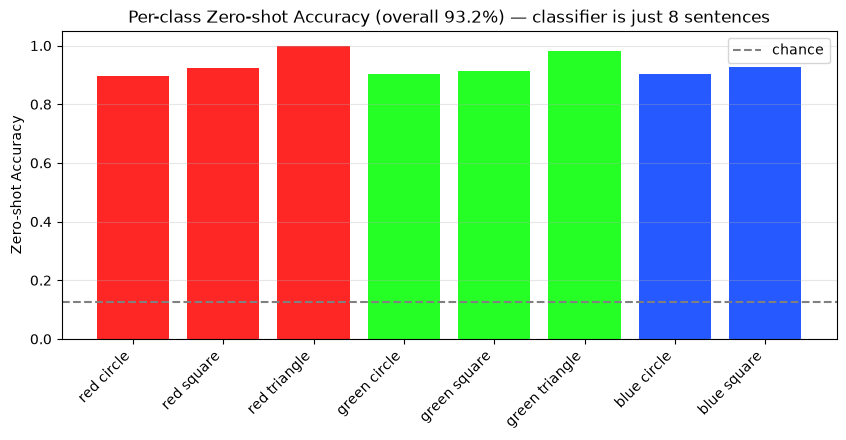

In [7]:
# 用8句话构造零样本分类器:每句话的嵌入向量=该类别的"分类器权重"
zp, _ = mlp_forward(txt_enc, np.array([caption_bow(c, s) for c, s in train_pairs]))

Xi_test, _, y_test_raw, _ = make_dataset(500, rng)
# 把全局9类标签映射到8个训练类的下标
pair_to_col = {ALL_PAIRS.index(p): j for j, p in enumerate(train_pairs)}
y_test = np.array([pair_to_col[t] for t in y_test_raw])

zi_test, _ = mlp_forward(img_enc, Xi_test)
# (500,32)@(32,8) -> 500x8相似度表,每行argmax即预测类别:分类=最近邻检索
pred = (zi_test @ zp.T).argmax(1)
acc = (pred == y_test).mean()
print(f'Zero-shot accuracy on 8 seen classes: {acc:.1%}  (chance = 12.5%)')

per_class = [(pred[y_test == k] == k).mean() for k in range(8)]
plt.figure(figsize=(10, 4))
bars = plt.bar(range(8), per_class, color=[COLORS[c] for c, s in train_pairs])
plt.xticks(range(8), names, rotation=45, ha='right')
plt.ylabel('Zero-shot Accuracy')
plt.title(f'Per-class Zero-shot Accuracy (overall {acc:.1%}) — classifier is just 8 sentences')
plt.axhline(1/8, color='gray', ls='--', label='chance')
plt.legend(); plt.ylim(0, 1.05); plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Text-to-Image Retrieval(以文搜图)

#### 💻 代码解读

**做什么:** 演示对齐空间的另一个直接应用:给一句话,从 500 张测试图里检索最匹配的 3 张。

**怎么做:**
- 查询句子经文本塔编码,与所有测试图像的嵌入算余弦相似度;
- `np.argsort(-sims)[:3]`:对相似度取负再升序排序 = 降序排序,切片取前 3(NumPy 没有直接的降序 argsort,这是惯用技巧);
- 检索和分类在 CLIP 里是同一个操作的两个方向——图搜文是分类,文搜图是检索,共用同一个相似度矩阵。

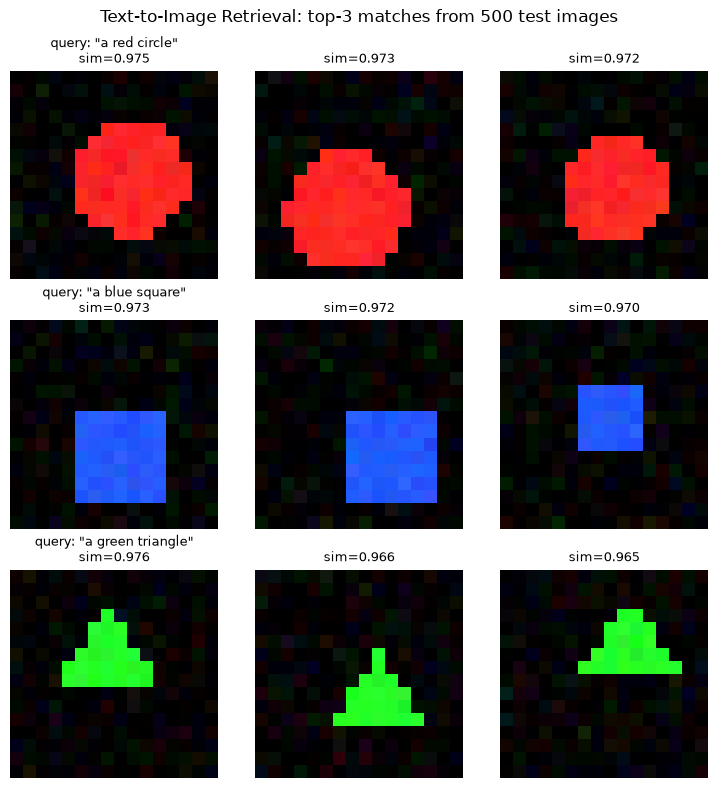

In [8]:
queries = [('red', 'circle'), ('blue', 'square'), ('green', 'triangle')]
fig, axes = plt.subplots(3, 3, figsize=(7.5, 8))
for row, (c, s) in enumerate(queries):
    zq, _ = mlp_forward(txt_enc, caption_bow(c, s)[None, :])  # [None,:]增加batch维
    sims = (zi_test @ zq.T).ravel()
    # 降序排序技巧:argsort(-x)等价于对x从大到小排序,取前3个下标
    top3 = np.argsort(-sims)[:3]
    for col, idx in enumerate(top3):
        ax = axes[row, col]
        ax.imshow(Xi_test[idx].reshape(IMG, IMG, 3))
        # axis('off')会隐藏ylabel,因此第一列用标题携带查询语句
        if col == 0:
            ax.set_title(f'query: "a {c} {s}"\nsim={sims[idx]:.3f}', fontsize=9)
        else:
            ax.set_title(f'sim={sims[idx]:.3f}', fontsize=9)
        ax.axis('off')
plt.suptitle('Text-to-Image Retrieval: top-3 matches from 500 test images')
plt.tight_layout(); plt.show()

## Shared Embedding Space Visualization(共享嵌入空间可视化)

#### 💻 代码解读

**做什么:** 用 PCA 把 32 维嵌入空间降到 2 维,同时画出图像嵌入(圆点)和文本嵌入(叉),直观看到两个模态"住进了同一个空间"。

**怎么做:**
- 把 400 个图像嵌入和 8 个文本嵌入拼在一起做 PCA:对中心化矩阵做 `np.linalg.svd`,右奇异向量 `Vt` 的前两行就是方差最大的两个主方向,`@ Vt[:2].T` 完成投影(SVD 实现 PCA 是数值上最稳的做法);
- 图像点按真实类别着色,文本叉标注句子。训练后可以看到:同类图像聚成簇,而**对应的文本嵌入恰好落在图像簇的中心附近**——零样本分类有效的几何原因一目了然。

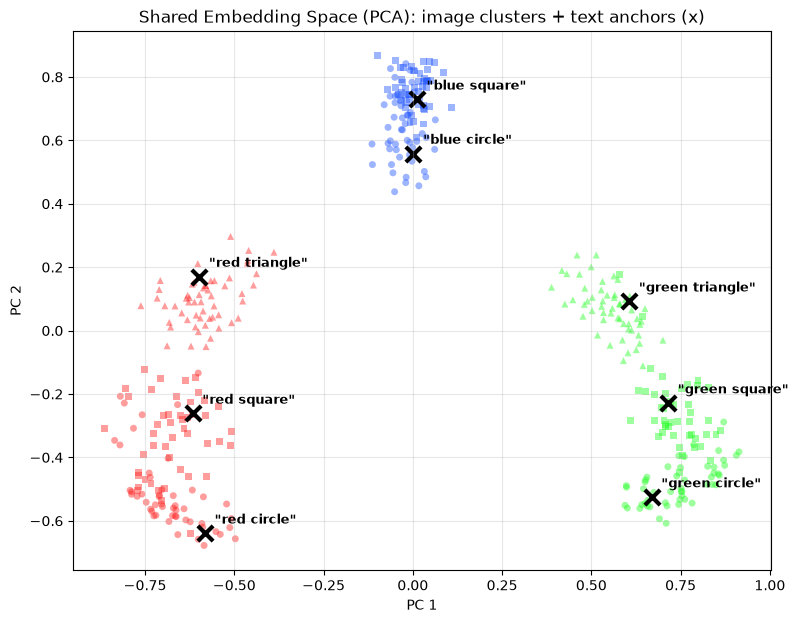

In [9]:
Xi_vis, _, y_vis_raw, _ = make_dataset(400, rng)
y_vis = np.array([pair_to_col[t] for t in y_vis_raw])
zi_vis, _ = mlp_forward(img_enc, Xi_vis)

# PCA via SVD:先中心化,右奇异向量的前2行=前2个主成分方向
allz = np.vstack([zi_vis, zp])
allz_c = allz - allz.mean(0)
U, S, Vt = np.linalg.svd(allz_c, full_matrices=False)
proj = allz_c @ Vt[:2].T  # 投影到2维,形状:(408,32)->(408,2)
pi, pt = proj[:len(zi_vis)], proj[len(zi_vis):]

plt.figure(figsize=(9, 7))
markers = {'circle': 'o', 'square': 's', 'triangle': '^'}
for k, (c, s) in enumerate(train_pairs):
    sel = y_vis == k
    plt.scatter(pi[sel, 0], pi[sel, 1], c=[COLORS[c]], marker=markers[s],
                s=25, alpha=0.45, edgecolors='none')
for k, (c, s) in enumerate(train_pairs):
    plt.scatter(pt[k, 0], pt[k, 1], c='black', marker='x', s=120, linewidths=3)
    plt.annotate(f'"{c} {s}"', pt[k], textcoords='offset points',
                 xytext=(7, 7), fontsize=9, weight='bold')
plt.title('Shared Embedding Space (PCA): image clusters + text anchors (x)')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.grid(True, alpha=0.3)
plt.show()

## Compositional Generalization Test: "blue triangle"(组合泛化测试:从未见过的"蓝色三角形")

#### 💻 代码解读

**做什么:** 终极考验——模型见过蓝色(圆/方)也见过(红/绿)三角形,但**从未见过蓝色三角形**。它能把两个概念组合起来吗?

**怎么做:**
- 生成 300 张 blue triangle 图像,在**全部 9 句提示词**(含 "a blue triangle")中做零样本分类;
- 统计预测分布:正确率只有约 20%(随机 11%),误判几乎全部流向"blue circle"和"blue square"——**颜色几乎全对、形状大多错**的不对称混淆:颜色是像素级特征,容易跨组合迁移;形状需要空间模式,难以跨组合迁移;
- 文本端其实没问题——词袋向量天然可组合("blue"+"triangle" 的向量就是两者之和);瓶颈在图像塔:它从未见过这种像素组合,颜色与形状特征在其内部纠缠。**结论:组合泛化能力主要来自数据的规模与多样性,而不是对比目标本身**——这正是真实 CLIP 需要 4 亿图文对的原因。

Zero-shot accuracy on UNSEEN "blue triangle": 20.3%  (chance = 11.1%)
vs 93.2% on seen classes -> compositional generalization is hard!


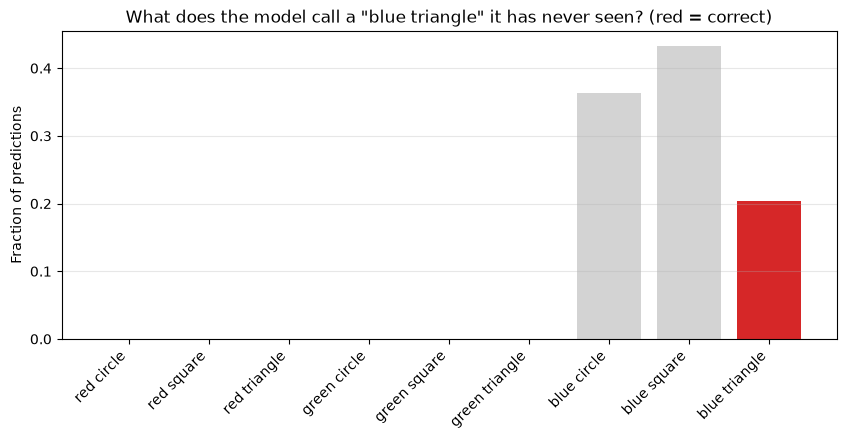

In [10]:
# 生成从未在训练中出现的组合:blue triangle
Xi_ho, _, _, _ = make_dataset(300, rng, include_holdout=True)
zi_ho, _ = mlp_forward(img_enc, Xi_ho)

# 这次用全部9句提示词(包括"a blue triangle")做零样本分类
zp9, _ = mlp_forward(txt_enc, np.array([caption_bow(c, s) for c, s in ALL_PAIRS]))
pred9 = (zi_ho @ zp9.T).argmax(1)
ho_idx = ALL_PAIRS.index(('blue', 'triangle'))
ho_acc = (pred9 == ho_idx).mean()
print(f'Zero-shot accuracy on UNSEEN "blue triangle": {ho_acc:.1%}  (chance = 11.1%)')
print(f'vs {acc:.1%} on seen classes -> compositional generalization is hard!')

# np.bincount统计每个类别被预测的次数,minlength保证长度为9
counts = np.bincount(pred9, minlength=9)
names9 = [f'{c} {s}' for c, s in ALL_PAIRS]
plt.figure(figsize=(10, 4))
colors9 = ['#d62728' if i == ho_idx else 'lightgray' for i in range(9)]
plt.bar(range(9), counts / len(pred9), color=colors9)
plt.xticks(range(9), names9, rotation=45, ha='right')
plt.ylabel('Fraction of predictions')
plt.title('What does the model call a "blue triangle" it has never seen? (red = correct)')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Key Takeaways(要点总结)

1. **Contrastive alignment**: Two independent encoders are aligned into one space purely by the symmetric InfoNCE objective — the diagonal of the similarity matrix emerges from noise
2. **Zero-shot = retrieval**: Classification becomes nearest-neighbor search over sentence embeddings; classes are defined by language, not architecture
3. **Temperature matters**: The learnable temperature (init 0.07) controls how sharply the model separates pairs
4. **Loss floors are informative**: Duplicate captions cap InfoNCE at ln(duplicates) — a "stuck" loss can hide a fully-trained model
5. **Compositionality is bought with data**: 93% on seen concepts vs ~20% on the held-out combination shows open-vocabulary power comes from data scale/diversity

1. **对比对齐(Contrastive alignment)**:两个互不共享参数的编码器,仅靠对称 InfoNCE 目标就被"焊"进同一空间——相似度矩阵的对角线从噪声中浮现
2. **零样本 = 检索**:分类变成在句子嵌入中找最近邻;类别由语言定义,而非网络结构
3. **温度是关键**:可学习温度(初始 0.07)控制模型区分正负配对的"锐利程度"
4. **损失下限有信息量**:重复标题使 InfoNCE 存在 ln(重复数) 的下限——损失"卡住"不代表没学好
5. **组合泛化是数据买来的**:见过的概念 93% vs 未见组合约 20%,说明开放词表能力来自数据规模与多样性

**与本仓库其他论文的联系:** 图像塔的前身是 AlexNet/ResNet(Papers 7/10/15);真实 CLIP 的文本塔是 Transformer(Paper 13);对比学习的"检索式分类"思想与 DPR(Paper 28)同源;而 CLIP 正是从这些零件通向 LLaVA、GPT-4V 等现代 VLM 的桥梁。